<a href="https://colab.research.google.com/github/adimika04-collab/Jaringan-Saraf-Tiruan/blob/main/Proyek_UTS_JST_Mika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET INFORMATION
Jumlah Data  : 299
Jumlah Kolom : 13

Nama Variabel:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']

5 Data Pertama:
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00           

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



HASIL MODEL : Logistic Regression

Accuracy : 0.8
ROC-AUC  : 0.824

Confusion Matrix
[[34  1]
 [11 14]]

Classification Report
              precision    recall  f1-score   support

           0       0.76      0.97      0.85        35
           1       0.93      0.56      0.70        25

    accuracy                           0.80        60
   macro avg       0.84      0.77      0.77        60
weighted avg       0.83      0.80      0.79        60


HASIL MODEL : Artificial Neural Network (MLP)

Accuracy : 0.667
ROC-AUC  : 0.771

Confusion Matrix
[[28  7]
 [13 12]]

Classification Report
              precision    recall  f1-score   support

           0       0.68      0.80      0.74        35
           1       0.63      0.48      0.55        25

    accuracy                           0.67        60
   macro avg       0.66      0.64      0.64        60
weighted avg       0.66      0.67      0.66        60


PERBANDINGAN PERFORMA MODEL
                             Model  Accuracy  R

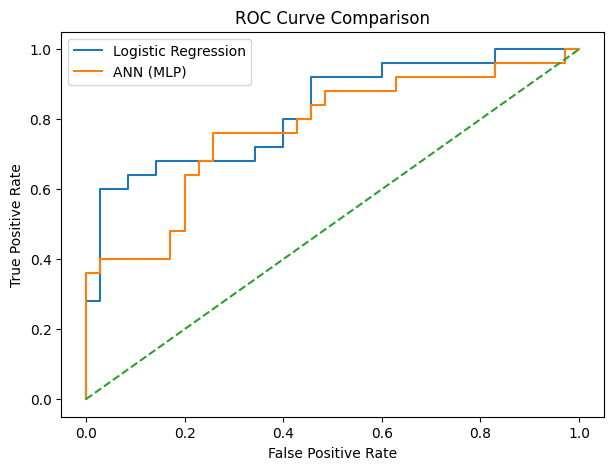

In [2]:
# ======================================
# 1. IMPORT LIBRARY
# ======================================
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier


# ======================================
# 2. LOAD DATA
# ======================================
data = pd.read_csv("/content/heart_failure_clinical_records_dataset.csv")

print("================================================")
print("DATASET INFORMATION")
print("================================================")
print("Jumlah Data  :", data.shape[0])
print("Jumlah Kolom :", data.shape[1])
print("\nNama Variabel:")
print(list(data.columns))

print("\n5 Data Pertama:")
print(data.head())


# ======================================
# 3. PREPROCESSING
# ======================================
X = data.drop("DEATH_EVENT", axis=1)
y = data["DEATH_EVENT"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ======================================
# 4. TRAIN MODEL
# ======================================
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

mlp_model = MLPClassifier(
    hidden_layer_sizes=(16,8),
    activation="relu",
    max_iter=1000,
    random_state=42
)

mlp_model.fit(X_train, y_train)


# ======================================
# 5. FUNGSI EVALUASI MODEL
# ======================================
def evaluate_model(model, name):

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)

    cm = confusion_matrix(y_test, pred)

    print("\n================================================")
    print(f"HASIL MODEL : {name}")
    print("================================================")

    print("\nAccuracy :", round(acc,3))
    print("ROC-AUC  :", round(auc,3))

    print("\nConfusion Matrix")
    print(cm)

    print("\nClassification Report")
    print(classification_report(y_test, pred))

    return prob, acc, auc


# ======================================
# 6. EVALUASI MODEL
# ======================================
prob_log, acc_log, auc_log = evaluate_model(log_model, "Logistic Regression")
prob_mlp, acc_mlp, auc_mlp = evaluate_model(mlp_model, "Artificial Neural Network (MLP)")


# ======================================
# 7. PERBANDINGAN MODEL
# ======================================
print("\n================================================")
print("PERBANDINGAN PERFORMA MODEL")
print("================================================")

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Artificial Neural Network (MLP)"],
    "Accuracy": [round(acc_log,3), round(acc_mlp,3)],
    "ROC-AUC": [round(auc_log,3), round(auc_mlp,3)]
})

print(comparison)


# ======================================
# 8. VISUALISASI ROC CURVE
# ======================================
fpr_log, tpr_log, _ = roc_curve(y_test, prob_log)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, prob_mlp)

plt.figure(figsize=(7,5))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_mlp, tpr_mlp, label="ANN (MLP)")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()